# Class task


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



In [71]:
titanic_df = pd.read_csv("titanic.csv")

In [72]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [73]:
titanic_df = titanic_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])


In [74]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [75]:
titanic_df = titanic_df.drop(columns = ["SibSp", "Parch"])

In [76]:
titanic_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [77]:
df = pd.DataFrame(titanic_df)

In [78]:
df["Age"] = df["Age"].fillna(df["Age"].median())


In [79]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})


In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


In [66]:
df.head()

,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,Survived_1
0,3,0,22.0,7.2500,False,True,False
1,1,1,38.0,71.2833,False,False,True
2,3,1,26.0,7.9250,False,True,True
3,1,1,35.0,53.1000,False,True,True
4,3,0,35.0,8.0500,False,True,False


In [ ]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

KeyError: "None of [Index(['Embarked'], dtype='str')] are in the [columns]"

In [84]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [86]:
linear_reg = LinearRegression()
linear_reg.fit(X,y)

ValueError: could not convert string to float: 'S'

In [59]:
y_pred = linear_reg.predict(X_test)


In [60]:
y_pred

array([21.24751812, 34.26202394, 26.85757172, 27.96497624, 20.5345255 ,
       34.20243275, 24.09272045, 26.58587948, 24.09272045, 35.61999748,
       40.58712311, 26.85420085, 25.56355412, 26.33313457, 34.19460651,
       35.2662798 , 35.73252192, 24.09058467, 34.19460651, 40.61678678,
       26.85835916, 36.43377645, 21.16919015, 26.82251466, 26.68026388,
       26.31890646, 40.72820926, 29.32528675, 26.31890646, 26.03850992,
       26.85835916, 21.17200011, 40.64798252, 26.04671327, 21.98488108,
       26.13818494, 36.19242205, 24.09272045, 34.94948833, 26.85835916,
       32.56310471, 26.88128108, 26.85420085, 29.78301128, 25.31721387,
       26.14429531, 26.85128033, 26.82251466, 26.88116782, 38.42107154,
       20.31834208, 33.80736661, 26.31890646, 33.91371292, 29.78301128,
       34.18085918, 34.26202394, 29.11057799, 28.28857991, 24.08923632,
       26.86161677, 28.32903036, 28.15374505, 41.31995058, 29.78301128,
       33.44105288, 32.56310471, 26.85892007, 26.33302131, 33.67

In [61]:
SSE = np.sum(np.power((y_test - y_pred),2))


In [62]:
r2_score(y_test, y_pred)

0.23731380814982728

/tmp/ipykernel_17279/2543777623.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


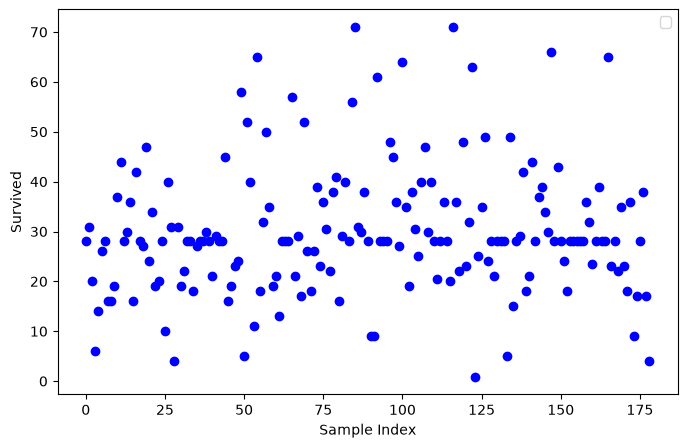

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(range(len(y_test)), y_test, color='blue', )
plt.xlabel('Age')
plt.ylabel('Survived')
plt.legend()
plt.show()

/home/meteora/dsml-11/.venv/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='Survived', ylabel='Pclass'>

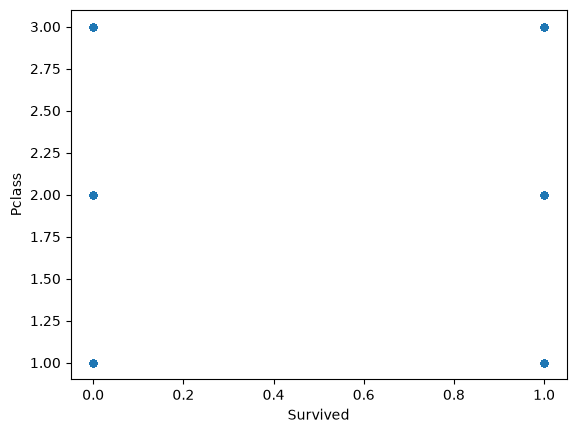

In [52]:
titanic_df.plot.scatter(x="Survived", y="Pclass", cmap="Dark2")